170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (5000, 32, 32, 3)
Test shape: (1000, 32, 32, 3)
Autoencoder training complete
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Compressed feature shape: (5000, 128)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Accuracy (Raw Images): 0.3569999933242798
SVM Accuracy (Compressed Features): 0.368
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


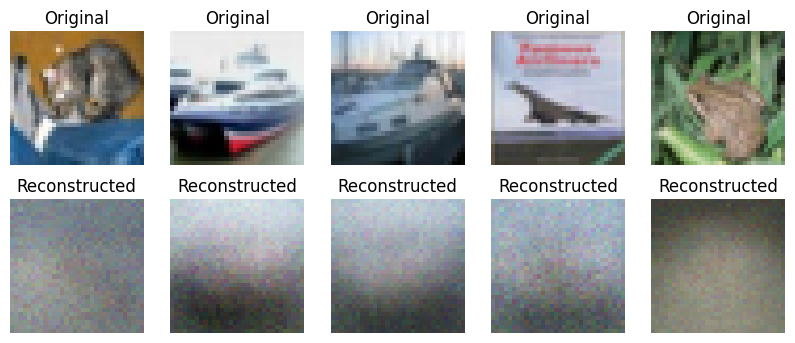

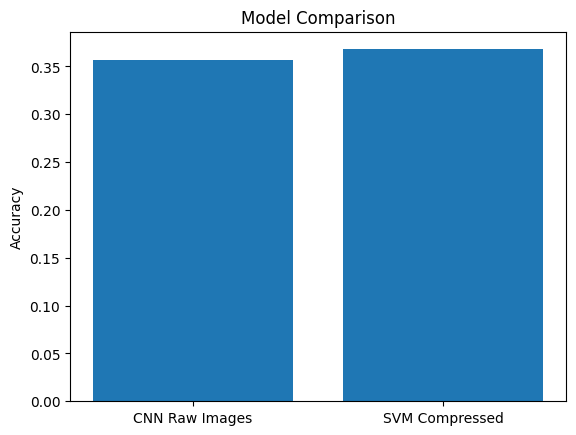


Final Comparison
-------------------
CNN (Raw Images): 0.3569999933242798
SVM (Compressed Features): 0.368


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# 1 Load CIFAR10 Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Use smaller subset for fast execution
x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# 2 AUTOENCODER (Compression)

input_img = Input(shape=(32,32,3))

x = Flatten()(input_img)
encoded = Dense(128, activation='relu')(x)

decoded = Dense(32*32*3, activation='sigmoid')(encoded)
decoded = Reshape((32,32,3))(decoded)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(optimizer='adam', loss='mse')

# Train quickly
autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=256,
    shuffle=True,
    verbose=0
)

print("Autoencoder training complete")

# 3 Compress Features

train_features = encoder.predict(x_train)
test_features = encoder.predict(x_test)

print("Compressed feature shape:", train_features.shape)

# 4 CNN on Raw Images

cnn = Sequential([
    Conv2D(16,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

cnn.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    verbose=0
)

cnn_acc = cnn.evaluate(x_test, y_test, verbose=0)[1]

print("CNN Accuracy (Raw Images):", cnn_acc)

# 5 SVM on Compressed Features

svm = SVC(kernel='linear')

svm.fit(train_features, y_train.ravel())

svm_preds = svm.predict(test_features)

svm_acc = accuracy_score(y_test, svm_preds)

print("SVM Accuracy (Compressed Features):", svm_acc)

# 6 Reconstruct Images

decoded_imgs = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10,4))

for i in range(5):

    # original
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    # reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

# 7 Accuracy Comparison

models = ["CNN Raw Images", "SVM Compressed"]
acc = [cnn_acc, svm_acc]

plt.bar(models, acc)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

print("\nFinal Comparison")
print("-------------------")
print("CNN (Raw Images):", cnn_acc)
print("SVM (Compressed Features):", svm_acc)